# Workflows 6-10 — Multiple pretrained backbones × audit vs unaudit
## BRISC 2025 — RTX 4060 WSL2

**Catarina Bota | UCP**

Every workflow is trained on **both partitions** (audited and unaudited) with the identical hyper-parameter, seed and preprocessing configuration. The leakage delta per backbone is reported automatically.

**Workflows:**
- **W6:** ResNet50 (ImageNet) — direct comparator to the Fateh 2026 benchmark ($98.20\%$)
- **W7:** VGG16 (ImageNet) — Fateh 2026 secondary benchmark ($96.92\%$)
- **W8:** EfficientNetB2 (ImageNet) — replicates W4 for internal consistency check
- **W9:** ConvNeXt-Tiny (ImageNet) — modern CNN
- **W10:** RadImageNet-ResNet50 (medical-pretrained on 1.35M CT/MRI/US images) — the medically-pretrained argument

Each backbone runs the same 2-stage fine-tune protocol (head-only warmup + top-60 unfrozen).

> **Architecture note (why this notebook changed).** Under `set_memory_growth(True)`, TensorFlow never returns GPU memory to the OS inside a running process, and `clear_session()` only resets the graph. On an 8 GB laptop RTX 4060 shared with the Windows desktop, running all 5 backbones inside one kernel made every backbone after ResNet50 inherit an already-full GPU and **OOM** (that is why W7/W8/W9 previously failed — *not* missing weights; their ImageNet weights download fine from Keras).
>
> **Fix:** each `(backbone, dataset)` pair is now trained in its **own subprocess** (`train_one_backbone.py`), so the OS reclaims *all* VRAM the moment each run exits and every backbone starts on a clean GPU. Consequently **this notebook does not import TensorFlow** — if it did, the parent kernel would hold VRAM while the children run.

**Runtime:** ~2-3 h on RTX 4060 (5 backbones × 2 datasets × ~15 min each). Skip individual workflows via the `ACTIVE` set below.

**Prerequisites (WSL2):**
- `/root/brisc/data/brisc2025_clean/classification_task/` — audited
- `/root/brisc/data_unaudited/classification_task/` — official Fateh 2026 split
- The worker script `train_one_backbone.py` next to this notebook (single source of truth for the training code).
- For W10 only: RadImageNet-ResNet50 weights at `/root/brisc/radimagenet/RadImageNet-ResNet50_notop.h5` (see Section 5). If absent, W10 is skipped cleanly and the other four still complete.

## 1. Orchestration setup

The notebook kernel is a **pure orchestrator**: it only launches subprocesses and aggregates their results with pandas/matplotlib. No TensorFlow here.

In [1]:
import os, sys, json, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Python:', sys.executable)
print('This kernel deliberately does NOT import tensorflow (see architecture note above).')

Python: /root/brisc/.venv/bin/python3
This kernel deliberately does NOT import tensorflow (see architecture note above).


## 2. Configuration

In [2]:
SEED = 42
CLASSES = ['glioma', 'meningioma', 'no_tumor', 'pituitary']

# --- Dataset partitions (WSL2 paths) ---
DATASETS = {
    'audited':   '/root/brisc/data/brisc2025_clean/classification_task',
    'unaudited': '/root/brisc/data_unaudited/classification_task',
}

# --- Project paths ---
PROJECT_DIR = '/mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui'
OUT_ROOT    = f'{PROJECT_DIR}/leakage_backbones'
WORKER      = f'{PROJECT_DIR}/train_one_backbone.py'
os.makedirs(OUT_ROOT, exist_ok=True)

# Which workflows to actually run. Comment out any to skip.
ACTIVE = {
    'W6_ResNet50_ImageNet',
    'W7_VGG16_ImageNet',
    'W8_EfficientNetB2_ImageNet',
    'W9_ConvNeXtTiny_ImageNet',
    'W10_RadImageNet_ResNet50',
}

assert os.path.exists(WORKER), (
    f'Worker script not found at {WORKER}. It must sit next to this notebook.')
print('Active workflows:', sorted(ACTIVE))
print('Worker script   :', WORKER)
print('Output root     :', OUT_ROOT)

Active workflows: ['W10_RadImageNet_ResNet50', 'W6_ResNet50_ImageNet', 'W7_VGG16_ImageNet', 'W8_EfficientNetB2_ImageNet', 'W9_ConvNeXtTiny_ImageNet']
Worker script   : /mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/train_one_backbone.py
Output root     : /mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/leakage_backbones


## 3. Run each (backbone × dataset) in an isolated subprocess

Each call to `train_one_backbone.py` trains one backbone on one dataset, writes its artefacts (`model.h5`, `predictions.csv`, `confusion_matrix.csv`, `perclass.csv`, `history.json`) and a `metrics.json`, then exits — releasing all GPU memory. The loop below reads each `metrics.json` back and collects them.

A failed or skipped run (e.g. W10 without RadImageNet weights) still writes a `metrics.json` with an `error` field, so the loop never aborts.

In [4]:
results = []
for wf_name in sorted(ACTIVE):
    for ds_name, base_dir in DATASETS.items():
        print('\n' + '#' * 70)
        print(f'# LAUNCH  {wf_name}  /  {ds_name}')
        print('#' * 70, flush=True)

        cmd = [sys.executable, WORKER, wf_name, ds_name, base_dir, OUT_ROOT]
        proc = subprocess.run(cmd)   # stdout/stderr stream live into the notebook

        metrics_path = f'{OUT_ROOT}/{wf_name}/{ds_name}/metrics.json'
        if os.path.exists(metrics_path):
            with open(metrics_path) as f:
                row = json.load(f)
        else:
            row = {'workflow': wf_name, 'dataset': ds_name, 'accuracy': None,
                   'error': f'worker crashed (exit {proc.returncode}), no metrics.json'}
        results.append(row)

df = pd.DataFrame(results)
df.to_csv(f'{OUT_ROOT}/all_results.csv', index=False)
print('\nSaved', f'{OUT_ROOT}/all_results.csv')
df


######################################################################
# LAUNCH  W10_RadImageNet_ResNet50  /  audited
######################################################################


2026-07-02 17:21:14.792506: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-02 17:21:14.858027: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783009274.906419  114857 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783009274.919141  114857 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783009274.962676  114857 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

TF: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
  W10_RadImageNet_ResNet50  (audited)  batch=16
Wrote /mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/leakage_backbones/W10_RadImageNet_ResNet50/audited/metrics.json

######################################################################
# LAUNCH  W10_RadImageNet_ResNet50  /  unaudited
######################################################################


2026-07-02 17:21:20.526974: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-02 17:21:20.543669: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783009280.557754  114908 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783009280.561404  114908 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783009280.571746  114908 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

TF: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
  W10_RadImageNet_ResNet50  (unaudited)  batch=16
Wrote /mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/leakage_backbones/W10_RadImageNet_ResNet50/unaudited/metrics.json

######################################################################
# LAUNCH  W6_ResNet50_ImageNet  /  audited
######################################################################


2026-07-02 17:21:24.903305: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-02 17:21:24.914787: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783009284.927456  114958 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783009284.930860  114958 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783009284.942237  114958 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

TF: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
  W6_ResNet50_ImageNet  (audited)  batch=16
Found 3491 validated image filenames belonging to 4 classes.
Found 872 validated image filenames belonging to 4 classes.
Found 678 validated image filenames belonging to 4 classes.
Epoch 1/5


Traceback (most recent call last):
  File "/mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/train_one_backbone.py", line 348, in <module>
    main()
  File "/mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/train_one_backbone.py", line 332, in main
    row = train_workflow(name, WORKFLOWS[name], dataset_name, base_dir, out_root)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/train_one_backbone.py", line 239, in train_workflow
    h_a = top.fit(tr, validation_data=va, epochs=EPOCHS_HEAD, callbacks=[es_a], verbose=2)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/root/brisc/.venv/lib/python3.12/site-packages/keras/src/utils/traceback_utils.py", line 117, in error_handler
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/root/brisc/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/trainer.py"

KeyboardInterrupt: 

## 4. Comparison table + leakage delta per backbone

In [5]:
df = pd.read_csv(f'{OUT_ROOT}/all_results.csv')

cols = [c for c in ['workflow', 'dataset', 'accuracy', 'f1_macro', 'auc_ovr',
                    'ci95_lo', 'ci95_hi', 'inference_ms'] if c in df.columns]
print(df[cols].to_string(index=False))

# Compute leakage delta per workflow (unaudited - audited)
print('\n' + '=' * 70)
print('  LEAKAGE DELTA per backbone (unaudited vs audited)')
print('=' * 70)
deltas = []
for wf in df['workflow'].dropna().unique():
    sub = df[df['workflow'] == wf].set_index('dataset')
    if {'audited', 'unaudited'}.issubset(sub.index):
        a, u = sub.loc['audited'], sub.loc['unaudited']
        if pd.isna(a.get('accuracy')) or pd.isna(u.get('accuracy')):
            print(f'  {wf:35s}  incomplete (a run failed/skipped)')
            continue
        d_acc = u['accuracy'] - a['accuracy']
        ci_a  = (a['ci95_lo'], a['ci95_hi'])
        ci_u  = (u['ci95_lo'], u['ci95_hi'])
        overlap = not (ci_a[1] < ci_u[0] or ci_u[1] < ci_a[0])
        print(f'  {wf:35s}  Δacc {d_acc:+.2f} pp   CIs overlap? {"yes" if overlap else "NO"}')
        deltas.append({'workflow': wf, 'delta_acc_pp': d_acc,
                       'ci95_overlap': bool(overlap),
                       'audited_acc': a['accuracy'], 'unaudited_acc': u['accuracy']})

if deltas:
    pd.DataFrame(deltas).to_csv(f'{OUT_ROOT}/leakage_deltas.csv', index=False)
    print('\nSaved', f'{OUT_ROOT}/leakage_deltas.csv')

                  workflow   dataset  accuracy  f1_macro  auc_ovr  ci95_lo  ci95_hi  inference_ms
  W10_RadImageNet_ResNet50   audited       NaN       NaN      NaN      NaN      NaN           NaN
  W10_RadImageNet_ResNet50 unaudited       NaN       NaN      NaN      NaN      NaN           NaN
      W6_ResNet50_ImageNet   audited     97.49     97.56    99.80    96.17    98.53        149.36
      W6_ResNet50_ImageNet unaudited     98.00     98.18    99.94    97.10    98.80        140.68
         W7_VGG16_ImageNet   audited     97.94     97.96    99.86    96.61    98.97         17.87
         W7_VGG16_ImageNet unaudited     98.90     99.05    99.93    98.30    99.50         27.35
W8_EfficientNetB2_ImageNet   audited     93.95     94.18    99.30    92.18    95.72        232.08
W8_EfficientNetB2_ImageNet unaudited     95.30     95.78    99.61    93.90    96.60        250.75
  W9_ConvNeXtTiny_ImageNet   audited     94.99     95.16    99.63    93.36    96.61       2280.64
  W9_ConvNeXtTiny_Im

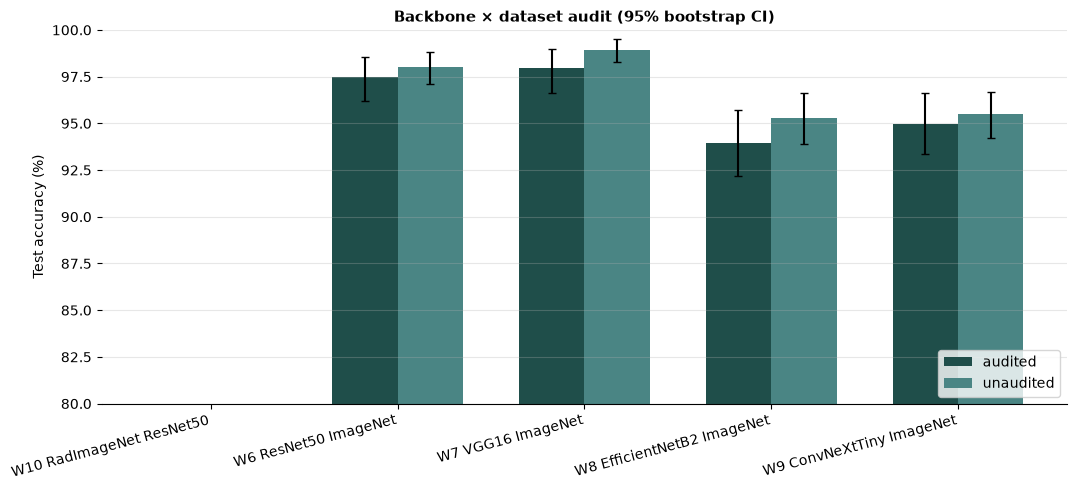

In [6]:
# Visual: paired-bar per workflow (audited vs unaudited) with error bars
df = pd.read_csv(f'{OUT_ROOT}/all_results.csv')
if len(df) > 0 and 'accuracy' in df.columns and df['accuracy'].notna().any():
    wfs = df['workflow'].dropna().unique()
    x = np.arange(len(wfs)); w = 0.35
    fig, ax = plt.subplots(figsize=(11, 5))
    for i, ds in enumerate(['audited', 'unaudited']):
        sub = df[df['dataset'] == ds].set_index('workflow')
        def g(wf, col):
            return sub.loc[wf, col] if wf in sub.index and pd.notna(sub.loc[wf, col]) else np.nan
        vals  = [g(wf, 'accuracy') if not np.isnan(g(wf, 'accuracy')) else 0 for wf in wfs]
        lows  = [(g(wf, 'accuracy') - g(wf, 'ci95_lo')) if not np.isnan(g(wf, 'ci95_lo')) else 0 for wf in wfs]
        highs = [(g(wf, 'ci95_hi') - g(wf, 'accuracy')) if not np.isnan(g(wf, 'ci95_hi')) else 0 for wf in wfs]
        ax.bar(x + (i - 0.5) * w, vals, w,
               label=ds, color='#1F4E4A' if ds == 'audited' else '#4A8584',
               yerr=[lows, highs], capsize=3, ecolor='black')
    ax.set_xticks(x)
    ax.set_xticklabels([wf.replace('_', ' ') for wf in wfs], rotation=15, ha='right')
    ax.set_ylim([80, 100]); ax.set_ylabel('Test accuracy (%)')
    ax.set_title('Backbone × dataset audit (95% bootstrap CI)',
                 fontsize=11, fontweight='bold')
    ax.legend(loc='lower right')
    for s in ['top', 'right', 'left']: ax.spines[s].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUT_ROOT}/backbone_leakage_comparison.png', bbox_inches='tight', dpi=150)
    plt.savefig(f'{OUT_ROOT}/backbone_leakage_comparison.pdf', bbox_inches='tight')
    plt.show()
else:
    print('No successful runs to plot yet.')

## 5. How to download the RadImageNet weights (W10)

RadImageNet is a ResNet50 pretrained on 1.35M CT/MRI/US images across 165 modalities and 11 anatomies (Mei et al. 2022, Radiology AI). These weights are **not** distributed with `keras.applications`; the file is ~100 MB.

**Manual download:**
1. Visit https://github.com/BMEII-AI/RadImageNet
2. Follow their Google Drive link for `RadImageNet-ResNet50_notop.h5`
3. Save to `/root/brisc/radimagenet/RadImageNet-ResNet50_notop.h5` (inside WSL)

```bash
mkdir -p /root/brisc/radimagenet
# then place RadImageNet-ResNet50_notop.h5 there (Google Drive download)
```

If the weights are not present, **W10 is skipped cleanly** (its `metrics.json` records the error) and the other four workflows still complete.

## 6. The worker script (single source of truth)

All TensorFlow / training logic lives in **`train_one_backbone.py`** next to this notebook:

- Hyper-parameters (`SEED=42`, `EPOCHS_HEAD=5`, `EPOCHS_FT=12`, `LR_HEAD=1e-3`, `LR_FT=1e-5`, `N_UNFREEZE=60`, `VAL_SPLIT=0.20`) — identical across backbones, mirroring W2-W5.
- Backbone factories, 2-stage fine-tune, evaluation, bootstrap CI, inference timing.
- **Per-backbone batch size** as an OOM safety net (`BATCH_OVERRIDE`): VGG16 / EfficientNetB2 / ConvNeXt use `batch=8` (vs `16` default) because their activation maps are much larger than ResNet50's. Lower these further if a run still OOMs.

To change training behaviour, edit the worker — not this notebook. Run a single pair from a terminal for debugging:

```bash
python train_one_backbone.py W7_VGG16_ImageNet audited \
    /root/brisc/data/brisc2025_clean/classification_task \
    "/mnt/c/Users/cbot/Desktop/BRISC pos graduação/brisc_gui/leakage_backbones"
```

## Notes

- **Output layout** mirrors W2/W3/W4/W5: each `(workflow, dataset)` pair has its own directory with `model.h5`, `predictions.csv`, `confusion_matrix.csv`, `perclass.csv`, `history.json`, plus a `metrics.json` consumed by this notebook.
- **Process isolation** is what makes all 5 backbones runnable back-to-back on an 8 GB GPU: each subprocess exit fully frees VRAM. Close other GPU consumers (browser, the Qt `app.py`, stray kernels) before a full run to maximise the free budget.
- **Consistent hyper-parameters** across all backbones: only `img_size`, `preprocessing_function` and (for OOM safety) `batch_size` vary per architecture.
- **Leakage delta per backbone** is the key finding for the journal: if all backbones show similar small deltas, the BRISC 2025 authors' de-duplication was effective; if some backbones show larger deltas, they are more sensitive to the residual near-duplicates.
- **Skipping**: comment out entries in the `ACTIVE` set (Section 2) to skip individual workflows if VRAM or time is limited.